In [1]:
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import random
from config import *

plt.rcParams['figure.dpi'] = 150
print(" Imports done")

Using device: cpu
 Imports done


In [2]:
def load_severity_images(severity_dir, folders_dict):
    data = {}
    for cls, folders in folders_dict.items():
        paths = []
        for folder in folders:
            folder_path = Path(severity_dir) / folder
            if not folder_path.exists():
                print(f"  Missing: {folder}")
                continue
            imgs = list(folder_path.glob('*.jpg')) + \
                   list(folder_path.glob('*.png'))
            paths.extend(imgs)
        data[cls] = paths
        print(f"  {cls:15s}: {len(paths)} images")
    return data

sev_data = load_severity_images(SEVERITY_DIR,
                                 SEVERITY_FOLDERS)
print(f"\nTotal: {sum(len(v) for v in sev_data.values())}")

  glioma         : 371 images
  meningioma     : 519 images
  neurocitoma    : 144 images
  normal         : 89 images
  outros         : 45 images
  schwannoma     : 100 images

Total: 1268


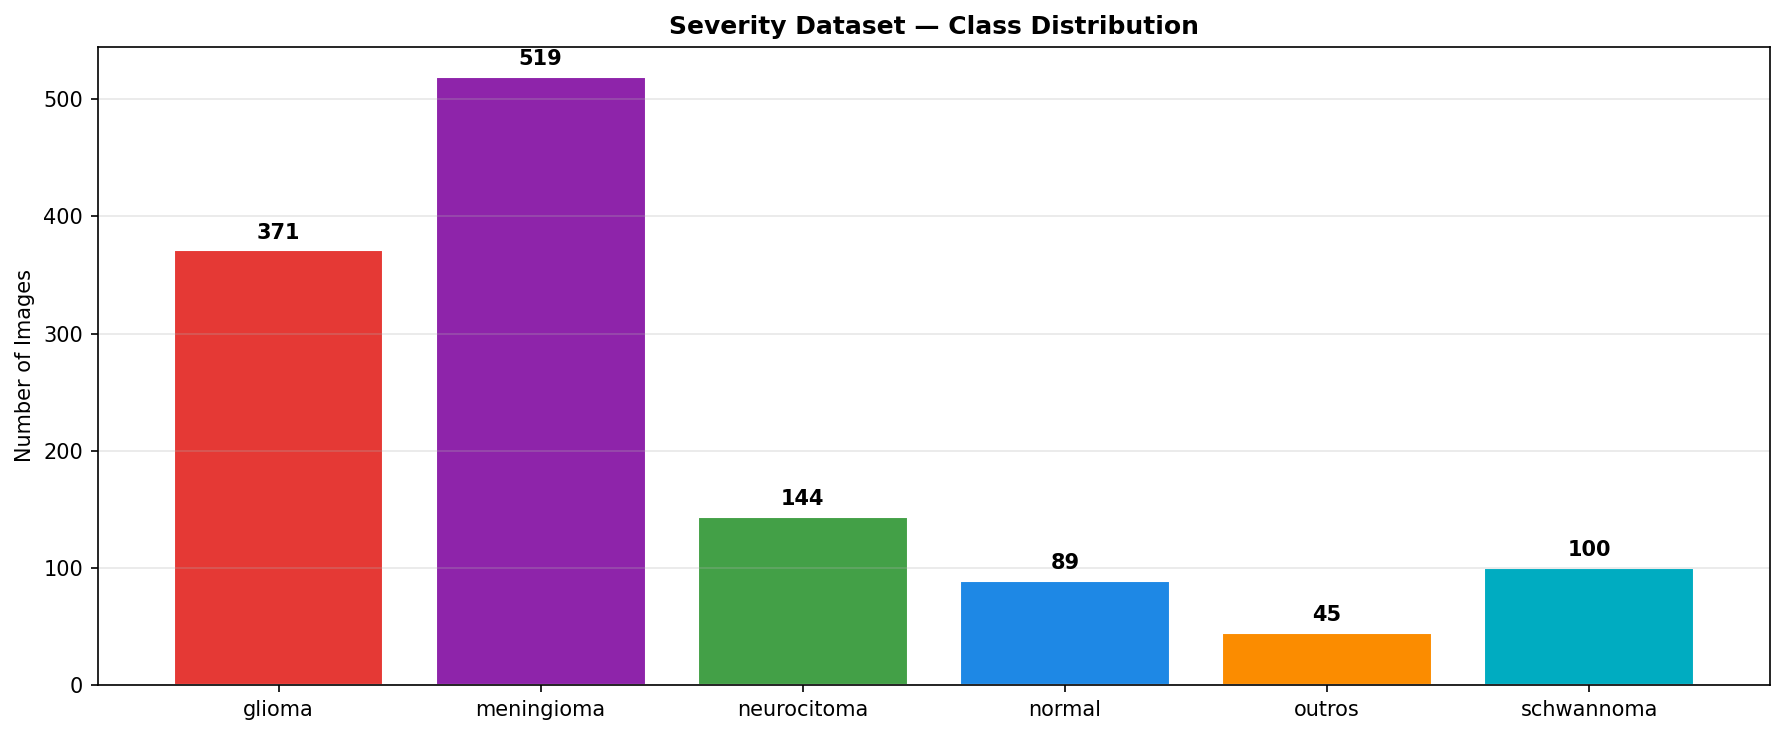

In [3]:
colors = ['#E53935','#8E24AA','#43A047',
          '#1E88E5','#FB8C00','#00ACC1']

classes = list(sev_data.keys())
counts  = [len(sev_data[c]) for c in classes]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(classes, counts,
              color=colors, edgecolor='white')
ax.set_title('Severity Dataset — Class Distribution',
             fontweight='bold')
ax.set_ylabel('Number of Images')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            str(val), ha='center', fontweight='bold')

plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / 'severity_class_dist.png')
plt.show()

In [4]:
max_cnt = max(counts)
min_cnt = min(counts)
ratio   = max_cnt / min_cnt

print(f"Max class : {classes[counts.index(max_cnt)]} "
      f"({max_cnt} images)")
print(f"Min class : {classes[counts.index(min_cnt)]} "
      f"({min_cnt} images)")
print(f"Imbalance ratio: {ratio:.2f}x")

if ratio > 3:
    print("  High imbalance — weighted loss needed")
elif ratio > 2:
    print("  Moderate imbalance — weighted loss recommended")
else:
    print(" Balanced enough")

Max class : meningioma (519 images)
Min class : outros (45 images)
Imbalance ratio: 11.53x
  High imbalance — weighted loss needed


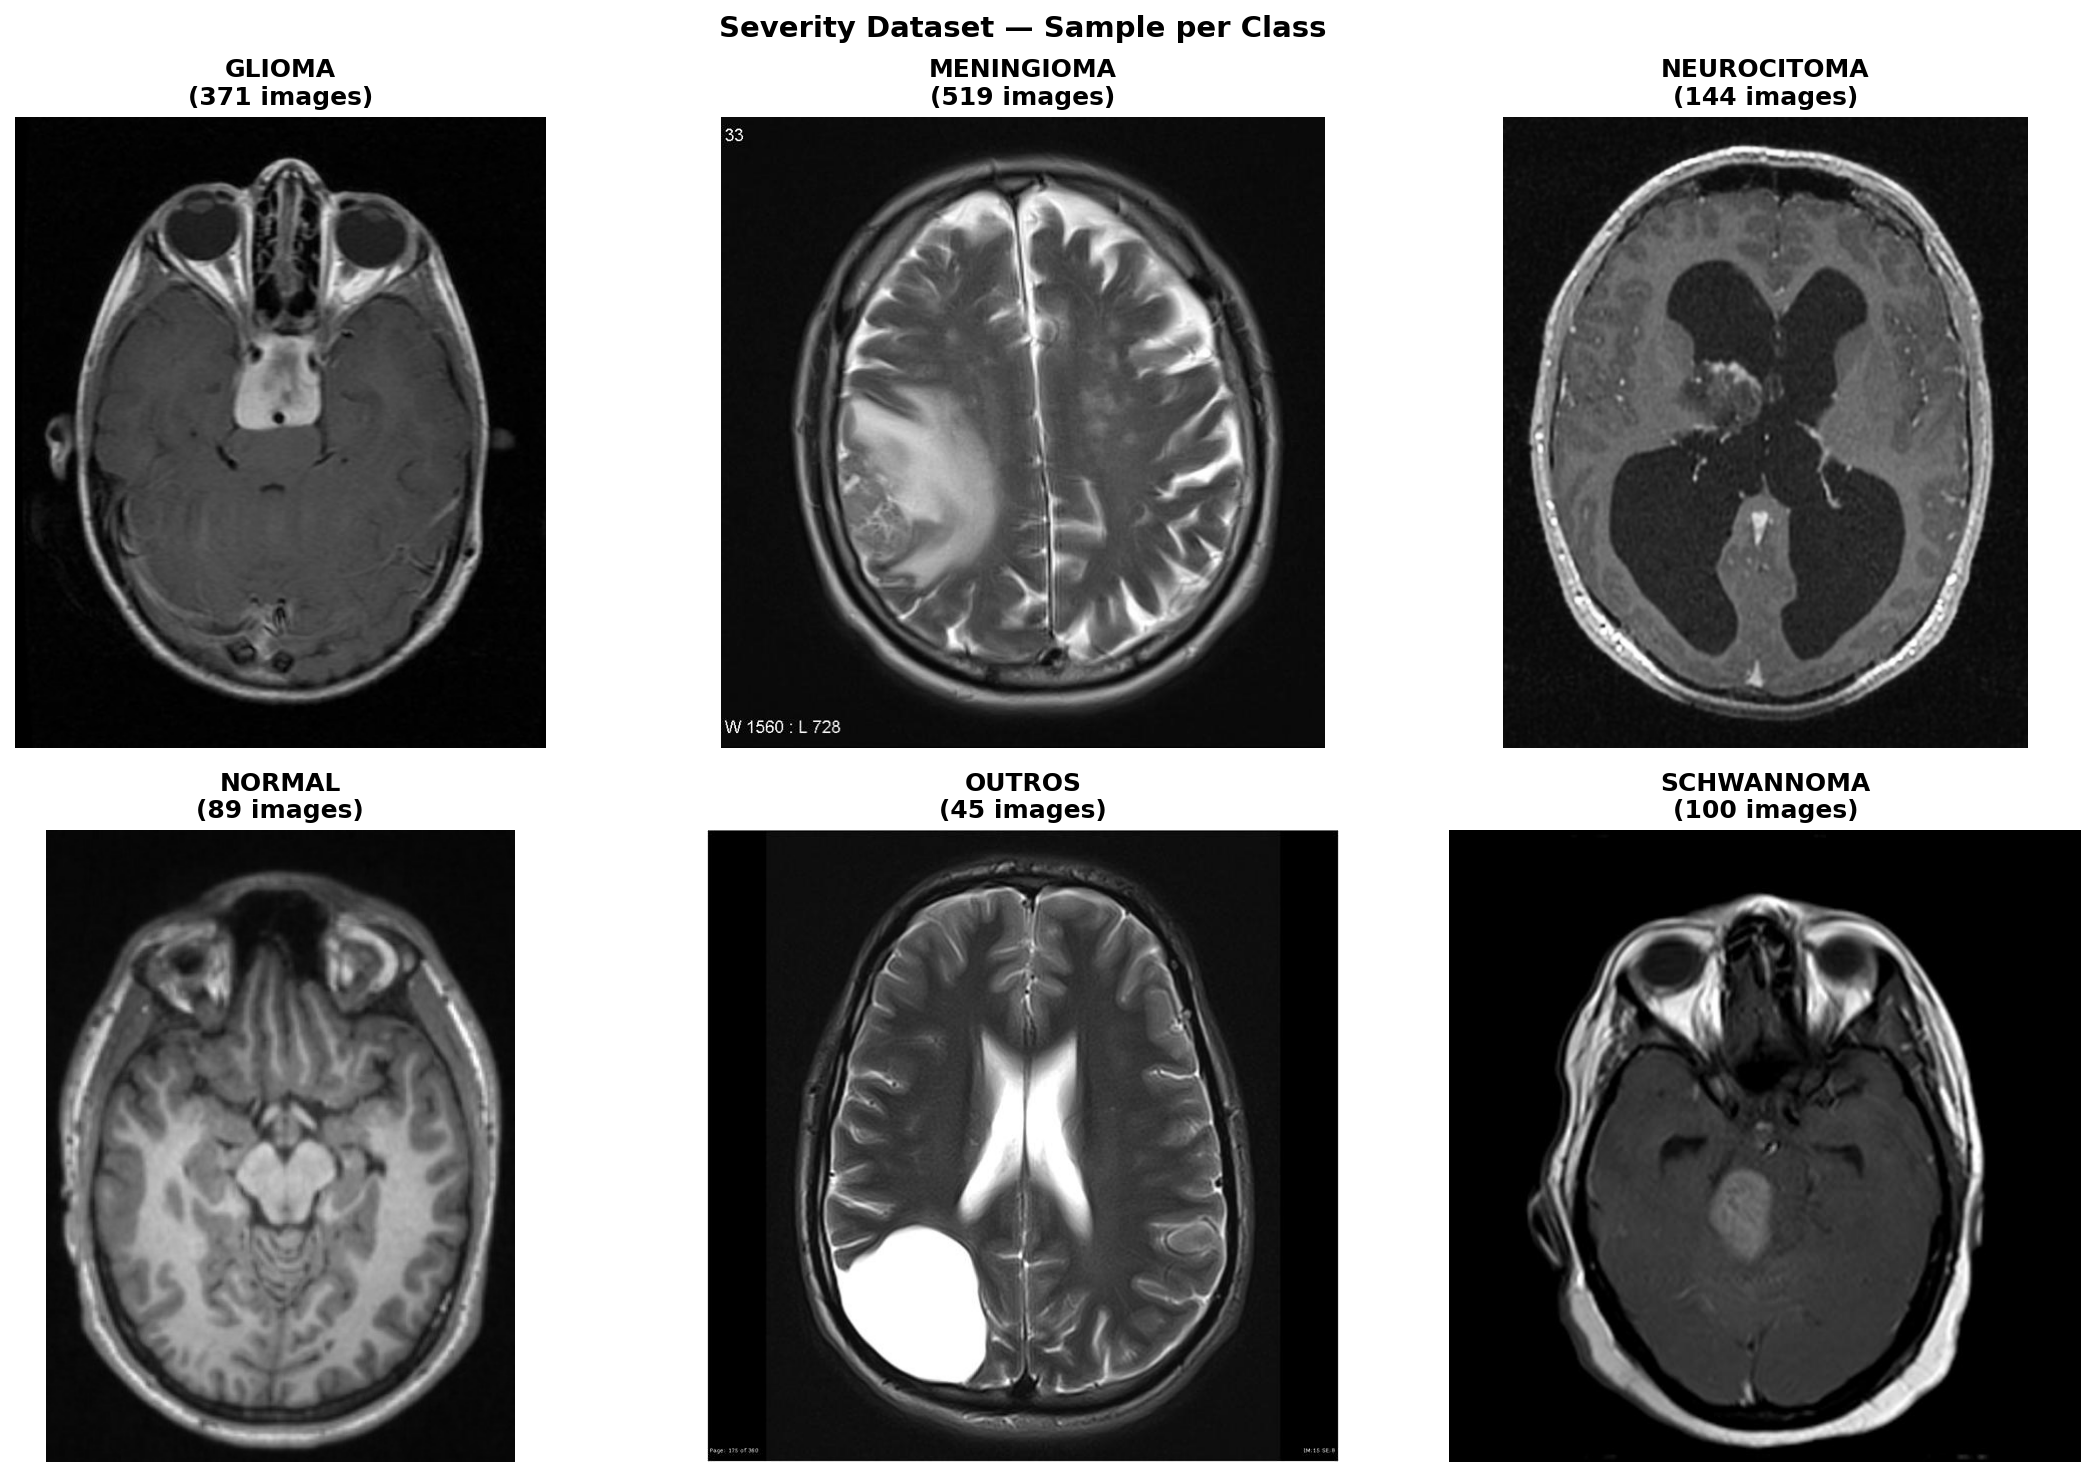

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    paths = sev_data[cls]
    img   = Image.open(random.choice(paths)).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].set_title(f'{cls.upper()}\n'
                        f'({len(sev_data[cls])} images)',
                        fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Severity Dataset — Sample per Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'severity_samples.png')
plt.show()

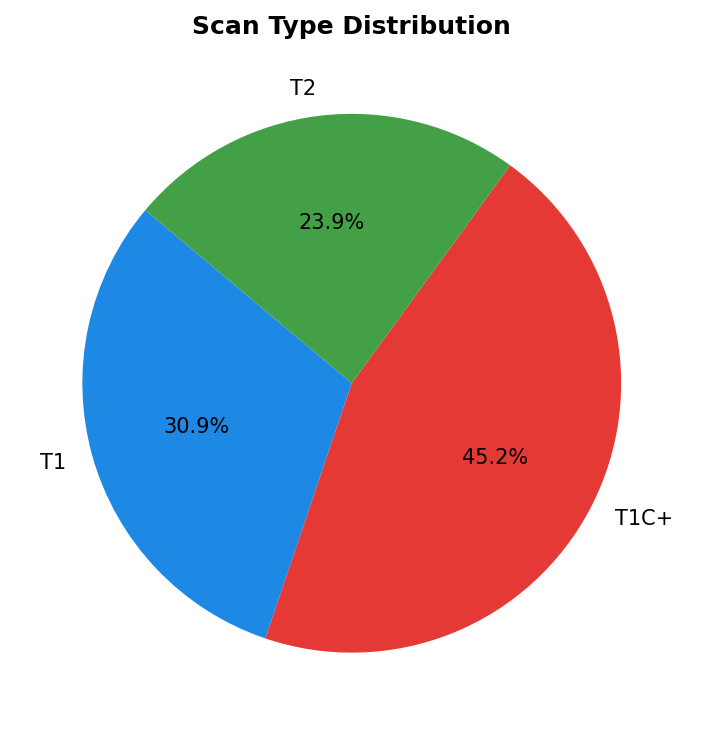

  T1   : 392 images
  T1C+ : 573 images
  T2   : 303 images


In [6]:
scan_counts = {'T1': 0, 'T1C+': 0, 'T2': 0}

for cls, folders in SEVERITY_FOLDERS.items():
    for folder in folders:
        folder_path = Path(SEVERITY_DIR) / folder
        if not folder_path.exists():
            continue
        n = len(list(folder_path.glob('*.jpg')) +
                list(folder_path.glob('*.png')))
        if 'T1C+' in folder:
            scan_counts['T1C+'] += n
        elif 'T2' in folder:
            scan_counts['T2']   += n
        else:
            scan_counts['T1']   += n

fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(scan_counts.values(),
       labels=scan_counts.keys(),
       colors=['#1E88E5','#E53935','#43A047'],
       autopct='%1.1f%%',
       startangle=140)
ax.set_title('Scan Type Distribution',
             fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'severity_scan_types.png')
plt.show()

for k, v in scan_counts.items():
    print(f"  {k:5s}: {v} images")

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    paths  = sev_data[cls]
    sample = random.sample(paths, min(80, len(paths)))
    pixels = []
    for p in sample:
        arr = np.array(
            Image.open(p).convert('RGB')
                         .resize((224, 224))
        )
        pixels.extend(arr.flatten().tolist())

    axes[idx].hist(pixels, bins=50,
                   color=colors[idx],
                   alpha=0.8, density=True)
    axes[idx].set_title(cls.upper())
    axes[idx].set_xlabel('Pixel Value')
    axes[idx].grid(alpha=0.3)

plt.suptitle('Pixel Intensity Per Severity Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'severity_pixel_intensity.png')
plt.show()

In [ ]:
all_paths = [p for paths in sev_data.values()
               for p in paths]
sample    = random.sample(all_paths, min(300, len(all_paths)))

widths  = [Image.open(p).size[0] for p in sample]
heights = [Image.open(p).size[1] for p in sample]

print("Image Size Analysis:")
print(f"  Width  — Min:{min(widths):4d} "
      f"Max:{max(widths):4d} "
      f"Mean:{np.mean(widths):.1f}")
print(f"  Height — Min:{min(heights):4d} "
      f"Max:{max(heights):4d} "
      f"Mean:{np.mean(heights):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30,
             color='#1E88E5', alpha=0.8)
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Pixels')
axes[0].grid(alpha=0.3)

axes[1].hist(heights, bins=30,
             color='#E53935', alpha=0.8)
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Pixels')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'severity_image_sizes.png')
plt.show()